In [1]:
using Pkg
Pkg.activate(".")
Pkg.update()

  Activating project at `~/Desktop/julia_codes/RandomLotkaVolterraCavity.jl/simulations`
    Updating registry at `~/.julia/registries/General.toml`
    Updating git-repo `/Users/mattiatarabolo/Desktop/julia_codes/RandomLotkaVolterraCavity.jl`
  No Changes to `~/Desktop/julia_codes/RandomLotkaVolterraCavity.jl/simulations/Project.toml`
  No Changes to `~/Desktop/julia_codes/RandomLotkaVolterraCavity.jl/simulations/Manifest.toml`


In [2]:
using RandomLotkaVolterraCavity
using Random, StatsBase, Distributions
using PyCall, PyPlot

## Erdos-Ranyi Random graph

In [3]:
using SpecialFunctions

In [4]:
# Function to calculate standard error of the mean
sem(x) = std(x) / sqrt(length(x))

# Function to calculate the standard error the median
semean(x) = sem(x)

function normalize!(prob::Vector{Float64})
    l = length(prob)
    norm = 0.0
    for k in 1:l
        norm += prob[k]
    end
    for k in 1:l
        prob[k] = prob[k] / norm
    end
end

function φ_func(x::Float64)
    return exp(-x^2/2)/sqrt(2*pi)
end

function Φ_func(x::Float64)
    return (1+erf(x/sqrt(2)))/2
end

w0_func(Δ) = Φ_func(Δ)
w1_func(Δ) = Δ * Φ_func(Δ) + φ_func(Δ)

w1_func (generic function with 1 method)

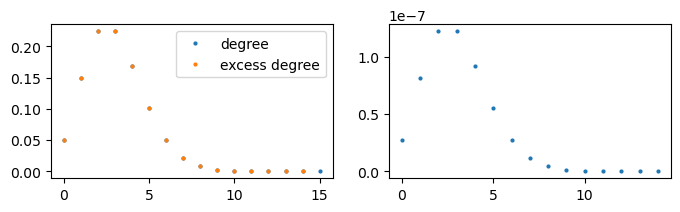

Mean Field stable region
norm degree: 0.9999999999999998, norm excess degree: 1.0


In [5]:
P = Int(1e3)  # Population size
K = 3  # Average degree of the graph
k_max = K*5
degree_pdf = Poisson(K)
p_k = pdf.(degree_pdf, 0:k_max)
normalize!(p_k)
p_cav_k = [(k+1)/K*p_k[k+2] for k in 0:k_max-1] # This is the excess degree distribution, i.e. the cavity degree distribution of an Erdos-Renyi random graph
normalize!(p_cav_k)
tol = 5e-3  # Convergence tolerance
max_iter = Int(1e2)  # Maximum number of iterations
m = 0.0  # Mean coupling
σ² = .5 # Standard deviation of coupling
γ = -1.0  # Correlation coefficient between J and J'

# check to be in the stable region
if (2*m^2/K+(1+γ)*σ²)^2/(m^2/K+σ²)<2*K/(K-1)
    println("Mean Field stable region")
else
    println("Mean field UNSTABLE region!")
end

fig, ax = subplots(1,2,figsize=(8,2))
ax[1].plot(0:k_max, p_k, markersize=4, linestyle="", marker=".", label="degree")
ax[1].plot(0:k_max-1, p_cav_k, markersize=4, linestyle="", marker=".", label="excess degree")
ax[1].legend()
ax[2].plot(0:k_max-1, abs.(p_cav_k.-p_k[1:k_max]), markersize=4, linestyle="", marker=".")
#ax.set_xlim((480,520))
PyPlot.display_figs()
println("norm degree: $(sum(p_k)), norm excess degree: $(sum(p_cav_k))")

In [10]:
mutable struct CheckVars
    avg_μ::Float64
    std_μ::Float64
end

function error_func(check_vars, μ_pop, q_pop, χ_pop)
    # Calculate new averages for convergence checking
    new_avg_μ = mean(μ_pop)
    new_std_μ = std(μ_pop)

    # Calculate the maximum change in the updates for convergence checking
    max_diff = max(abs(check_vars.avg_μ - new_avg_μ), abs(check_vars.std_μ - new_std_μ))
    check_vars.avg_μ = new_avg_μ
    check_vars.std_μ = new_std_μ

    return max_diff
end

ErrorException: invalid redefinition of constant Main.CheckVars

In [9]:
rng = Xoshiro(1234)
μ_population, q_population, χ_population, μ_cav_population, q_cav_population, χ_cav_population = population_dynamics(p_k, p_cav_k, P, tol, max_iter, m, σ², γ, K; check_vars=CheckVars(0.0,0.0), error_func=error_func, check_conv=10, rng=rng, verbose=false)

fig, ax = subplots(1, 3, figsize=(15, 5))
ax[1].hist(μ_population, bins=range(0.0, 6.0, length=20), density=true)
ax[1].set_xlabel("μ")
ax[1].set_ylabel("Frequency")
ax[2].hist(q_population, bins=range(0.0, 10.0, length=20), density=true)
ax[2].set_xlabel("q")
ax[3].hist(χ_population, bins=range(0.0, 2.0, length=20), density=true)
ax[3].set_xlabel("χ")
tight_layout()
show()
PyPlot.display_figs()

avg_μ = mean(μ_population)
stde_μ = semean(μ_population)

println("μ = $(avg_μ) ± $(stde_μ)")

ErrorException: setfield!: immutable struct of type CheckVars cannot be changed

## Random-Regular Graph

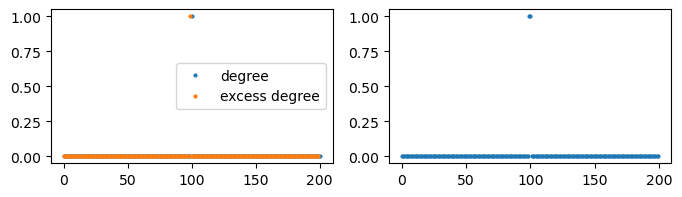

Mean Field stable region
norm degree: 1.0, norm excess degree: 1.0


In [13]:
P = Int(1e5)  # Population size
K = 100  # Average degree of the graph
k_max = K*2
degree_pdf =Poisson(K)
p_k = [Float64(k==K) for k in 0:k_max]
normalize!(p_k)
p_cav_k = [(k+1)/K*p_k[k+2] for k in 0:k_max-1] # This is the excess degree distribution, i.e. the cavity degree distribution of an Erdos-Renyi random graph
normalize!(p_cav_k)
tol = 1e-3  # Convergence tolerance
max_iter = Int(1e3)  # Maximum number of iterations
m = -1.0  # Mean coupling
σ² = 1.0 # Standard deviation of coupling
γ = -1.0  # Correlation coefficient between J and J'

# check to be in the stable region
if (2*m^2/K+(1+γ)*σ²)^2/(m^2/K+σ²)<2*K/(K-1)
    println("Mean Field stable region")
else
    println("Mean field UNSTABLE region!")
end

fig, ax = subplots(1,2,figsize=(8,2))
ax[1].plot(0:k_max, p_k, markersize=4, linestyle="", marker=".", label="degree")
ax[1].plot(0:k_max-1, p_cav_k, markersize=4, linestyle="", marker=".", label="excess degree")
ax[1].legend()
ax[2].plot(0:k_max-1, abs.(p_cav_k.-p_k[1:k_max]), markersize=4, linestyle="", marker=".")
#ax.set_xlim((480,520))
PyPlot.display_figs()
println("norm degree: $(sum(p_k)), norm excess degree: $(sum(p_cav_k))")

Progress: 100%|█████████████████████████████████████████| Time: 0:01:07


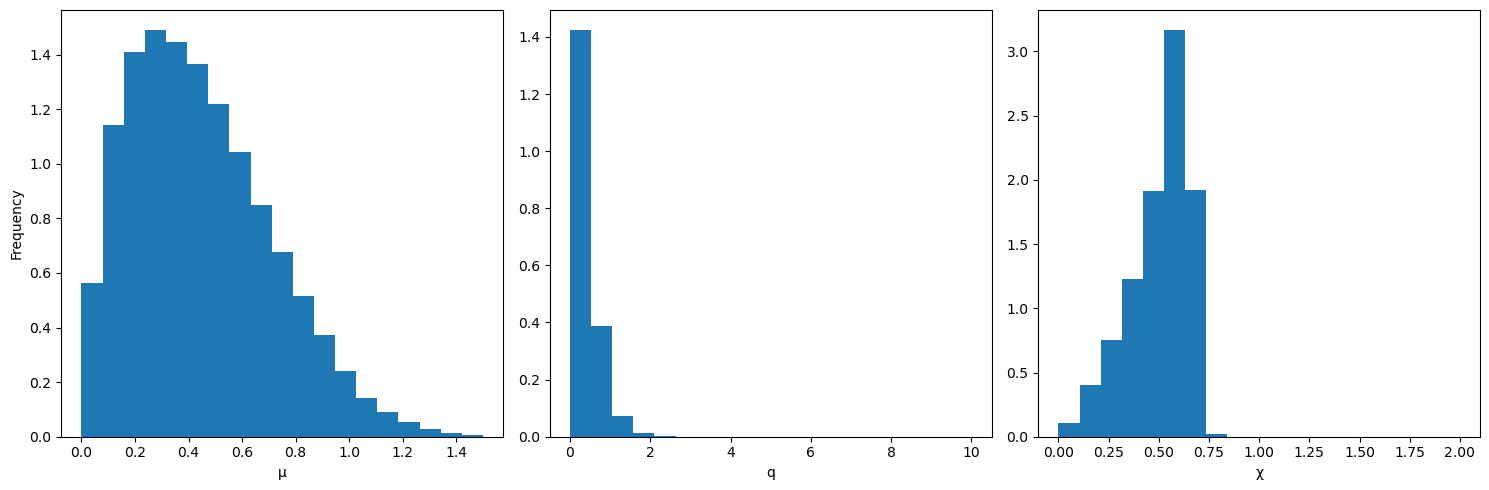

Converged after 10 iterations.
μ = 0.4475478789620867 ± 0.0008366698980062327


In [16]:
rng = Xoshiro(1234)
μ_population, q_population, χ_population, μ_cav_population, q_cav_population, χ_cav_population = population_dynamics(p_k, p_cav_k, P, tol, max_iter, m, σ², γ, K; check_conv=10, rng=rng, verbose=false)

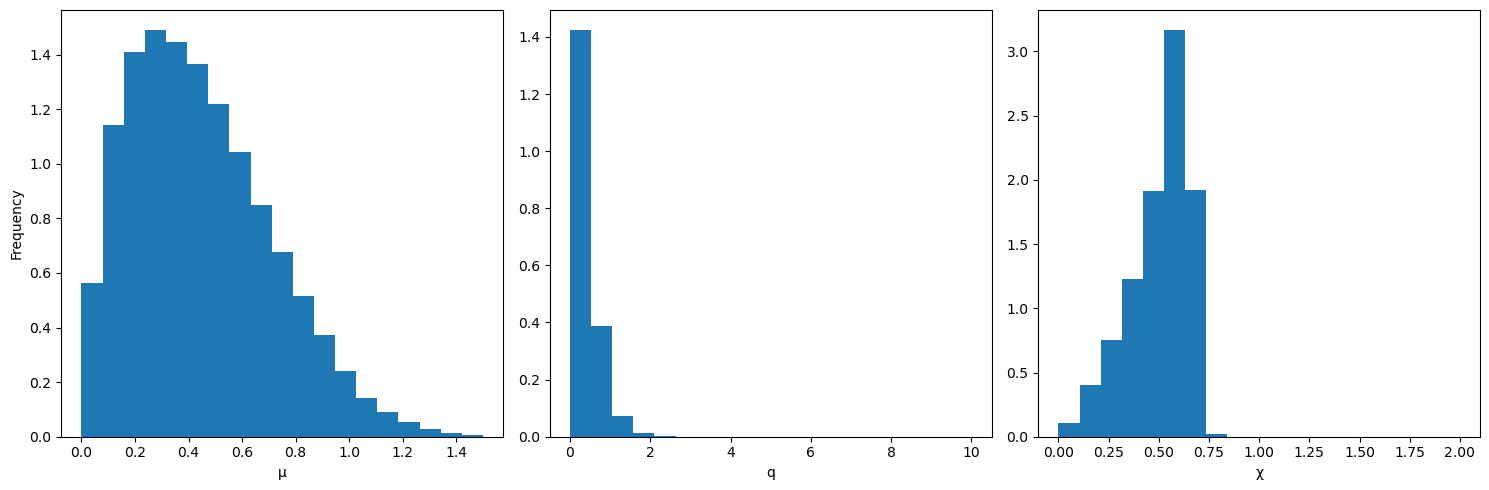

μ = 0.4475478789620867 ± 0.0008366698980062327


In [17]:
fig, ax = subplots(1, 3, figsize=(15, 5))
ax[1].hist(μ_population, bins=range(0.0, 1.5, length=20), density=true)
ax[1].set_xlabel("μ")
ax[1].set_ylabel("Frequency")
ax[2].hist(q_population, bins=range(0.0, 10.0, length=20), density=true)
ax[2].set_xlabel("q")
ax[3].hist(χ_population, bins=range(0.0, 2.0, length=20), density=true)
ax[3].set_xlabel("χ")
tight_layout()
show()
PyPlot.display_figs()

avg_μ = mean(μ_population)
stde_μ = semean(μ_population)

println("μ = $(avg_μ) ± $(stde_μ)")

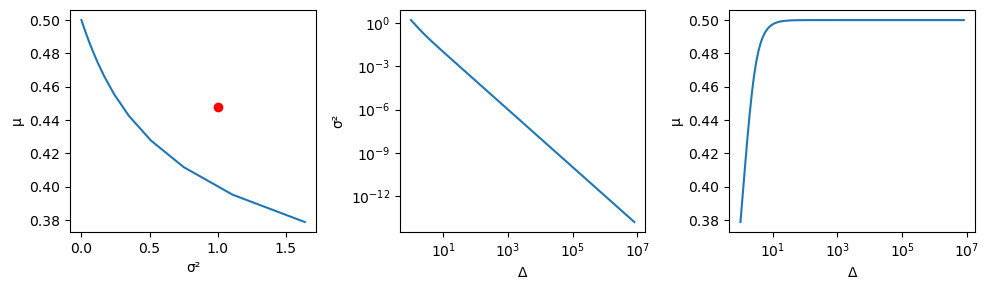

In [20]:
npoints = 100

Δs = 10 .^ (range(log(1.0), log(1000.0), length=npoints))
μs = zeros(npoints)
qs = zeros(npoints)
χs = zeros(npoints)
σs = zeros(npoints)

for (iΔ,Δ) in enumerate(Δs)
    w0 = w0_func(Δ)
    w1 = w1_func(Δ)
    w2 = w0+Δ*w1

    χs[iΔ] = w0+γ*w0^2/w2
    σs[iΔ] = w2/(w2+γ*w0)^2
    μs[iΔ] = (Δ/w1*w2/(w2+γ*w0)-m)^(-1)
    qs[iΔ] = (w2/(w2+γ*w0)*μs[iΔ]/(σs[iΔ]*w1))^2
end

colors = ["red", "orange", "yellow", "green", "blue"]

fig,ax = subplots(1,3,figsize=(10,3),tight_layout=true)
ax[1].plot(σs, μs)
ax[1].scatter([σ²], [avg_μ], color="red")
ax[1].set_xlabel("σ²")
ax[1].set_ylabel("μ")
ax[2].plot(Δs, σs)
ax[2].set_xscale("log")
ax[2].set_yscale("log")
ax[2].set_xlabel("Δ")
ax[2].set_ylabel("σ²")
ax[3].plot(Δs, μs)
ax[3].set_xlabel("Δ")
ax[3].set_ylabel("μ")
ax[3].set_xscale("log")
#ax[3].set_yscale("log")
PyPlot.display_figs()

## Fully Connected case

In [26]:
P = Int(1e4)  # Population size
tol = 1e-3  # Convergence tolerance
max_iter = Int(1e3)  # Maximum number of iterations
m = -1.0  # Mean coupling
σ² = 1.0 # Standard deviation of coupling
γ = -1.0  # Correlation coefficient between J and J'

# check to be in the stable region
if σ²<2/(1+γ)^2
    println("Mean Field stable region")
else
    println("Mean field UNSTABLE region!")
end

Mean Field stable region


In [27]:
rng = Xoshiro(1234)
μ_population, q_population, χ_population = population_dynamics_FC(P, tol, max_iter, m, σ², γ; check_conv=10, rng=rng, verbose=false)

Progress: 100%|█████████████████████████████████████████| Time: 0:03:13


Converged after 90 iterations.


([0.09039014690800412, 0.3159951519882759, 0.9247180163950672, 0.354433789588548, 1.1087002766740006, 0.12560172578588336, 0.3193090693498517, 0.05732551193591488, 0.403155332448018, 0.12420383201292759  …  0.32932152307115986, 0.6706387953743135, 0.08909427418185609, 0.24829800285525713, 0.8221174691438009, 0.7994385434287171, 0.43297537378490714, 0.36815061006509014, 0.5023534744221928, 0.503391769110193], [0.04057058051733809, 0.20082539926298598, 1.024076404730353, 0.23554334668081506, 1.4011248650099302, 0.06041868149342037, 0.20451033851047493, 0.023214516885578112, 0.28189177295128715, 0.059374609758083355  …  0.21251836049447242, 0.6043087465161621, 0.03984090705384357, 0.1445967216172647, 0.8415874793099717, 0.800405962973224, 0.3110568261437129, 0.2493252175251507, 0.38672288043420733, 0.392122412588599], [0.2206445193282167, 0.4851437959831155, 0.655808890597416, 0.5066195661704475, 0.6553193956919562, 0.28015667186222404, 0.47994752889000475, 0.15979733275304459, 0.54141522

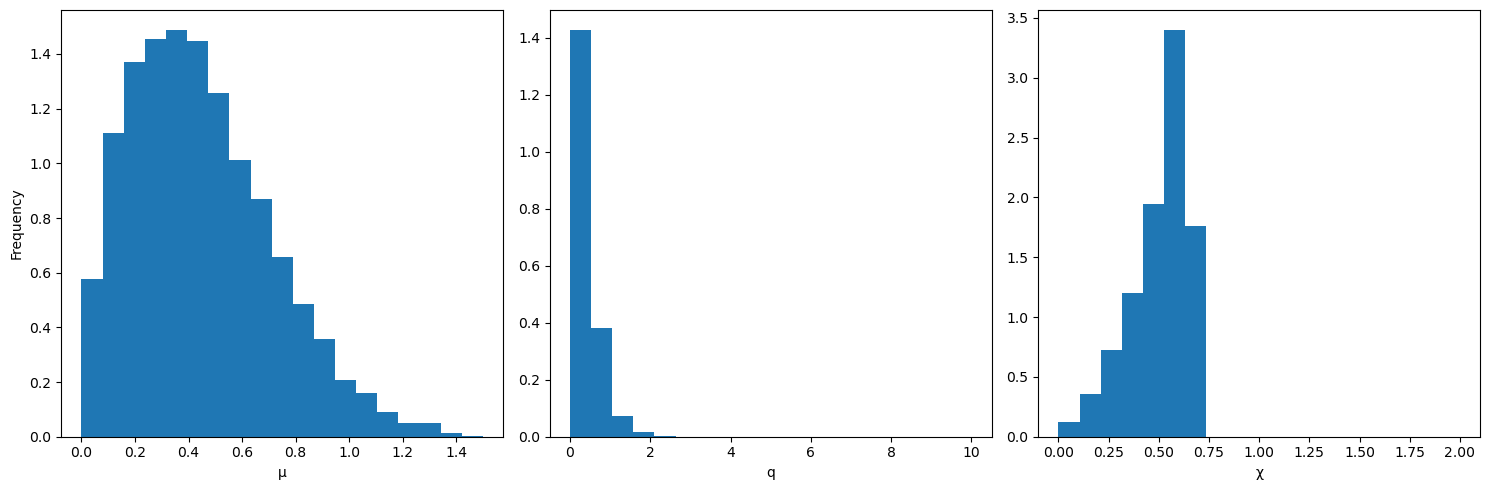

μ = 0.44773148750905345 ± 0.002646415960038298


In [28]:
fig, ax = subplots(1, 3, figsize=(15, 5))
ax[1].hist(μ_population, bins=range(0.0, 1.5, length=20), density=true)
ax[1].set_xlabel("μ")
ax[1].set_ylabel("Frequency")
ax[2].hist(q_population, bins=range(0.0, 10.0, length=20), density=true)
ax[2].set_xlabel("q")
ax[3].hist(χ_population, bins=range(0.0, 2.0, length=20), density=true)
ax[3].set_xlabel("χ")
tight_layout()
show()
PyPlot.display_figs()

avg_μ = mean(μ_population)
stde_μ = semean(μ_population)

println("μ = $(avg_μ) ± $(stde_μ)")

In [23]:
findall(x->x<1e-2, μ_population)

23-element Vector{Int64}:
  642
  681
 1019
 1076
 1252
 1327
 1927
 2207
 3392
 3749
    ⋮
 7797
 8357
 8420
 8528
 8736
 8787
 9258
 9499
 9580

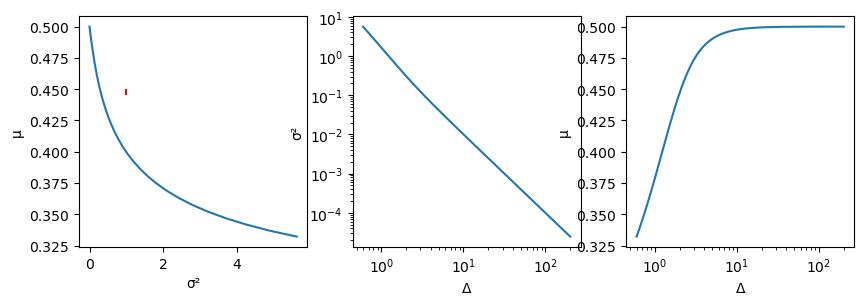

In [29]:
npoints = 100

Δs = 10 .^ (range(log(0.8), log(10.0), length=npoints))
μs = zeros(npoints)
qs = zeros(npoints)
χs = zeros(npoints)
σs = zeros(npoints)

for (iΔ,Δ) in enumerate(Δs)
    w0 = w0_func(Δ)
    w1 = w1_func(Δ)
    w2 = w0+Δ*w1

    χs[iΔ] = w0+γ*w0^2/w2
    σs[iΔ] = w2/(w2+γ*w0)^2
    μs[iΔ] = (Δ/w1*w2/(w2+γ*w0)-m)^(-1)
    qs[iΔ] = (w2/(w2+γ*w0)*μs[iΔ]/(σs[iΔ]*w1))^2
end

colors = ["red", "orange", "yellow", "green", "blue"]

fig,ax = subplots(1,3,figsize=(10,3))
ax[1].plot(σs, μs)
ax[1].errorbar(σ², avg_μ, yerr=stde_μ, color="red")
ax[1].set_xlabel("σ²")
ax[1].set_ylabel("μ")
ax[2].plot(Δs, σs)
ax[2].set_xscale("log")
ax[2].set_yscale("log")
ax[2].set_xlabel("Δ")
ax[2].set_ylabel("σ²")
ax[3].plot(Δs, μs)
ax[3].set_xlabel("Δ")
ax[3].set_ylabel("μ")
ax[3].set_xscale("log")
#ax[3].set_yscale("log")
PyPlot.display_figs()